# `self-seamfind` — matching seeds and sphere-tracing walkers, on the analytic benchmark

The method of `Self_ideas/test2_cagdas/seam_finder.md`, implemented as the package
`Self_ideas/test2_cagdas/seamfind` (one module per stage) and run through the Phase 4 harness
on the **tier-1 analytic corpus** (`out/bench_phase4`, 720 scenes, 12 strata). No rendered
data is read. Like notebook 16 it is a candidate for the project's own extractor, not one of
the paper's seven.

| stage (plan) | module | what it does |
|---|---|---|
| 0 synthetic scenes | — | **is** the benchmark generator (constructed truth, SCHEMA D19 `nominal` seams) |
| 1 preprocessing | `geom.py` | per-part spacing h, voxel downsample, oriented PCA normals, MLS projection Π_A, Π_B |
| 2a prefilter | `access.py` | cone of rays around each band point's normal, sphere-traced on the merged cloud |
| 3 seeds | `seeds.py` | cross-part nearest-neighbour pairs within τ_d = gap_max + 2h, θ_n, joint class; 3b coplanar boundary pairs |
| 4 walkers | `walk.py` | each seed walks on A towards B and on B towards A; toes, gap, root point |
| 5 assembly | `assemble.py` | DBSCAN on roots, split by normals, MST ordering, spline, torch frame, cross-run and toe rules |
| 2c torch check | `access.py` | generator torch cone (30°, 15 mm, work angle ≤ 45°) + bore confinement; output = weldable spans |
| 6 rolling ball | — | not implemented (optional in the plan, M9) |

**Inputs.** The condition's cloud split by `object_id` (the plan assumes labelled parts: the
"objects" oracle, the input `lit-lobb` gets at L0). Normals are always PCA estimates; only their
sign comes from the stored normals (`full_exterior`, the plan's synthetic rule) or the camera
(`single`, its real-scan rule).

**Where the plan was changed to fit the dataset** — 17 changes, each a parameter, listed with
the corpus fact that forced it in `seamfind/README.md`. The ISO-driven ones: gap bound 3 → 5 mm
(ISO 9692-1 ranges plus the ISO 5817 below-D tail reach 4.9 mm); h estimated (0.25–4 pts/mm²);
normal gating for 1 mm plates; same-plane test for "coplanar"; 25 mm coplanar pairing for ISO
9692-1 grooves; the generator's torch model, bore rule, cross-run rule and toe rule. The full
run carries the plan's own settings as the arm `plan`.

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, ".."); sys.path.insert(0, "../scripts"); sys.path.insert(0, "../Self_ideas/test2_cagdas")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import cKDTree
warnings.filterwarnings("ignore")
from baselines import prepare, run_matrix, spread
from baselines import self_seamfind as sk
from seamfind import Params, extract

FACTS = pd.read_csv("../out/bench_phase4/facts.csv")
def _fam(r):
    if isinstance(r.seam_family, str): return r.seam_family
    return "line_grooved" if (isinstance(r.prep, str) and r.prep != "square") else "line"
FACTS["family"] = FACTS.apply(_fam, axis=1); FACTS["stratum"] = FACTS.joint_type + "/" + FACTS.family
ORDER_STRATA = ["T/line", "T/circle", "T/ellipse", "T/saddle", "T/rounded_rect", "T/swept_path",
                "corner/line", "butt/line", "butt/line_grooved", "butt/arc_butt", "lap/line", "edge/line"]
ONE = {s: f"../out/bench_phase4/{g.iloc[0].joint_type}/{g.iloc[0].scene_id}" for s, g in FACTS.groupby("stratum")}

METHODS = ["lit-ransac", "lit-regiongrow", "lit-lobb", "lit-ppf", "lit-pcaslice", "lit-modelreg", "lit-quadric", "self-footprint", "self-seamfind"]
COLOR = dict(zip(METHODS[:8], ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]))
COLOR["self-seamfind"] = "#52514e"      # 9th entry: no 9th categorical hue - ink, never a generated colour
GRAY = "#b8b7b2"; INK = "#0b0b0b"; INK2 = "#52514e"
SEQ = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "xtick.color": INK2,
                     "ytick.color": INK2, "axes.titlesize": 10.5, "axes.titleweight": "bold",
                     "axes.titlecolor": INK, "font.size": 9, "legend.frameon": False,
                     "axes.grid": True, "grid.color": "#ecebe7", "grid.linewidth": 0.6})
def split(prep, view):
    c = prep.cloud(view, 0.0); lab = c["object_id"]
    kw = ({"cam_pos": np.asarray(prep.scene["camera"]["T_world_cam"], float)[:3, 3]} if view == "single"
          else {"normals_A": c["normals"][lab == 0], "normals_B": c["normals"][lab == 1]})
    return c, c["xyz"][lab == 0], c["xyz"][lab == 1], kw
print(Params())

Params(h_mm=None, outlier_k=12, outlier_std=3.0, remove_outliers=False, k_normals=25, r_mls_h=3.0, mls_normal_gate=0.5, support_h=0.75, prefilter=True, n_rays=24, cone_half_deg=60.0, tau_vis=0.04, ray_start_h=0.05, ray_hit_h=0.5, ray_free_mm=40.0, ray_max_steps=60, gap_max_mm=5.0, tau_d_extra_h=2.0, seeding='oneway', n_fps=1500, coplanar_pairs=True, coplanar_tau_mm=25.0, coplanar_deg=20.0, facing_deg=150.0, coplanar_tol_mm=0.5, alpha=0.9, eps_h=0.05, tol_h=0.01, k_max=50, crease_free='interior', crease_fit_h=6.0, angle_check=False, angle_disagree_deg=10.0, dbscan_eps_h=4.0, dbscan_min=5, dbscan_eps_spacing=3.0, normal_eps=0.35, suppress_toes=True, min_seam_mm=10.0, cross_runs=True, cross_run_tol_deg=45.0, close_h=3.0, ds_mm=2.0, torch_check=True, torch_half_deg=30.0, torch_standoff_mm=15.0, max_work_deg=45.0, travel_deg=(-15.0, 0.0, 15.0), work_step_deg=15.0, bore_check=True, bore_min_diameter_mm=80.0, output='weldable', dihedral_min_deg=30.0, dihedral_max_deg=170.0, extra={})


## One scene through the stages — a straight T joint

Seeds (Stage 3, grey: one-way nearest-neighbour pairs, a band), their walkers' toes on A and B
(Stage 4, blue / orange), the root points (black) and the assembled weldable seams (Stage 5,
ink) against the constructed truth (green), plus a cross-section at mid-length showing a toe
pair, the two fitted supporting planes and the root on their intersection.

{'n_A': 33360, 'n_B': 70884, 'band_A': 3686, 'band_B': 2071, 'seeds': 5577, 'seeds_coplanar_3b': 0, 'seeds_converged': 5577, 'seeds_angle_drop': 0, 'seeds_kept': 5577, 'seed_spacing_mm': 0.022, 'cross_runs_dropped': 0, 'toes_suppressed': 0} h = 0.79 mm
timings (s): {'stage1': 1.144, 'bands': 0.681, 'stage2a': 2.648, 'stage3': 0.006, 'stage4': 2.54, 'stage5': 0.675, 'stage2c': 0.484}
  S0: fillet   L =  132.3 mm  gap ~ 0.98 mm (truth 0.17)  dihedral ~ 98 deg (design 96)  weldable 1.00
  S1: fillet   L =  128.7 mm  gap ~ 0.63 mm (truth 0.17)  dihedral ~ 82 deg (design 96)  weldable 1.00
  S2: fillet   L =  128.3 mm  gap ~ 1.44 mm (truth 0.17)  dihedral ~ 98 deg (design 96)  weldable 1.00
  S3: fillet   L =   46.2 mm  gap ~ 1.46 mm (truth 0.17)  dihedral ~ 82 deg (design 96)  weldable 1.00
  S4: fillet   L =   37.7 mm  gap ~ 1.11 mm (truth 0.17)  dihedral ~ 82 deg (design 96)  weldable 1.00
  S5: fillet   L =   19.2 mm  gap ~ 1.02 mm (truth 0.17)  dihedral ~ 82 deg (design 96)  weldable 1

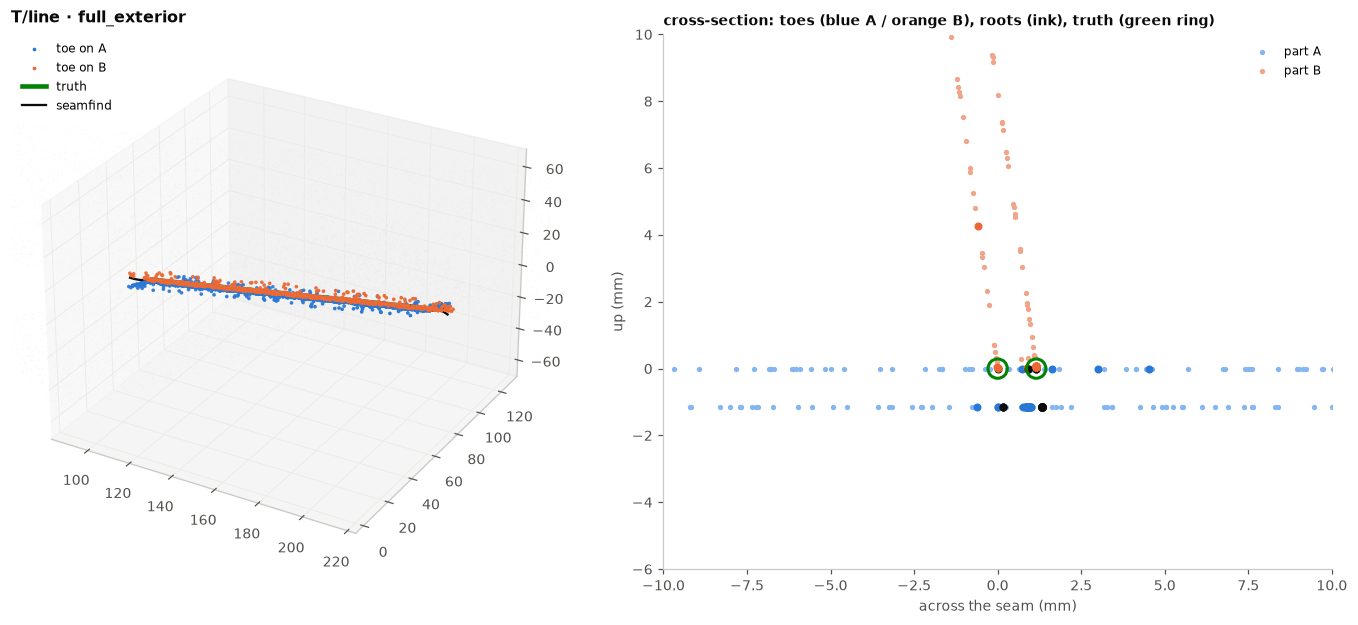

In [2]:
FAM, VIEW = "T/line", "full_exterior"
prep = prepare([ONE[FAM]])[0]
c, A, B, kw = split(prep, VIEW)
r = extract(A, B, Params(), **kw)
sd = r.seeds
print({k: v for k, v in r.counts.items()}, "h = %.2f mm" % r.h)
print("timings (s):", r.timings)
for i, s in enumerate(r.seams):
    print(f"  S{i}: {s['joint_class']:8s} L = {s['length']:6.1f} mm  gap ~ {np.nanmedian(s['gap']):.2f} mm (truth {prep.facts['root_gap_mm']:.2f})  "
          f"dihedral ~ {np.nanmedian(s['dihedral']):.0f} deg (design {prep.facts['included_angle_deg']:.0f})  weldable {np.mean(s['weldable']):.2f}")
G = np.vstack([np.asarray(g) for g in prep.gt]); ctr = G.mean(0)
fig = plt.figure(figsize=(13, 5.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
st = max(1, len(c["xyz"]) // 15000); ax.scatter(*c["xyz"][::st].T, s=0.5, color="#d5d4cf", alpha=0.35, linewidths=0)
ok = sd["ok"]; sub = np.flatnonzero(ok)[::max(1, ok.sum() // 1500)]
ax.scatter(*sd["toeA"][sub].T, s=2, color="#2a78d6", label="toe on A"); ax.scatter(*sd["toeB"][sub].T, s=2, color="#eb6834", label="toe on B")
for g in prep.gt: ax.plot(*np.asarray(g).T, color="#008300", linewidth=3, label="truth" if g is prep.gt[0] else None)
for i, s in enumerate(r.seams): ax.plot(*s["points"].T, color=INK, linewidth=1.5, label="seamfind" if i == 0 else None)
span = 0.5 * np.ptp(G, axis=0).max() + 15
ax.set_xlim(ctr[0] - span, ctr[0] + span); ax.set_ylim(ctr[1] - span, ctr[1] + span); ax.set_zlim(ctr[2] - span, ctr[2] + span)
ax.view_init(28, -60); ax.legend(fontsize=8, loc="upper left"); ax.set_title(f"{FAM} · {VIEW}", loc="left")
# cross-section at the mid-point of the first truth seam
g0 = np.asarray(prep.gt[0]); m = g0[len(g0) // 2]; t = g0[-1] - g0[0]; t /= np.linalg.norm(t)
up = np.array([0, 0, 1.0]); e1 = np.cross(up, t); e1 /= np.linalg.norm(e1); e2 = np.cross(t, e1)
ax2 = fig.add_subplot(1, 2, 2)
for lab_, col in ((0, "#86b6ef"), (1, "#f0a58a")):
    q = c["xyz"][c["object_id"] == lab_]; q = q[np.abs((q - m) @ t) < 0.8]
    ax2.scatter((q - m) @ e1, (q - m) @ e2, s=6, color=col, label=f"part {'AB'[lab_]}")
near = np.flatnonzero(ok & (np.abs((sd["root"] - m) @ t) < 0.8) & (np.linalg.norm(sd["root"] - m, axis=1) < 8))
for j in near[:40]:
    for P_, col in ((sd["toeA"][j], "#2a78d6"), (sd["toeB"][j], "#eb6834"), (sd["root"][j], INK)):
        ax2.scatter([(P_ - m) @ e1], [(P_ - m) @ e2], s=18, color=col, zorder=5)
for gpoly in prep.gt:
    gp = np.asarray(gpoly); i = np.argmin(np.abs((gp - m) @ t))
    ax2.scatter([(gp[i] - m) @ e1], [(gp[i] - m) @ e2], s=160, facecolor="none", edgecolor="#008300", linewidth=2, zorder=6)
ax2.set_aspect("equal"); ax2.set_xlim(-10, 10); ax2.set_ylim(-6, 10); ax2.grid(False)
ax2.set_xlabel("across the seam (mm)"); ax2.set_ylabel("up (mm)"); ax2.legend(fontsize=8, loc="upper right")
ax2.set_title("cross-section: toes (blue A / orange B), roots (ink), truth (green ring)", loc="left", fontsize=9)
plt.tight_layout(); plt.show()

## Round 1 — one scene per stratum, run live

The first scene of each stratum, both conditions, the default parameters, two seeds each. No
stage draws a random number (FPS is seeded and only in the `fps` arm), so the two seeds must
agree exactly.

In [3]:
rows = []; t0 = time.time()
for st in ORDER_STRATA:
    prep = prepare([ONE[st]])
    for view in ("full_exterior", "single"):
        df = run_matrix(prep, methods=[sk.spec()], seeds=[0, 1], verify_seeds=2, view=view)
        df["stratum"] = st; df["condition"] = view; rows.append(df)
R1 = pd.concat(rows, ignore_index=True)
print(f"{len(R1)} rows in {time.time() - t0:.0f}s")
sp = pd.concat([spread(R1[R1.condition == v]) for v in ("full_exterior", "single")])
assert (sp.spread == 0).all(); print(f"zero spread over seeds on all {len(sp)} scene x condition cells: deterministic\n")
t = R1[R1.seed == 0].pivot_table(index="stratum", columns="condition", values=["f1", "precision", "recall", "n_pred_seams"]).reindex(ORDER_STRATA)
print(t.round(2).to_string())

48 rows in 239s
zero spread over seeds on all 24 scene x condition cells: deterministic

                             f1         n_pred_seams            precision               recall       
condition         full_exterior single full_exterior single full_exterior single full_exterior single
stratum                                                                                              
T/line                     0.98   0.99           6.0    1.0          0.96   0.97          1.00   1.00
T/circle                   0.76   0.42           2.0    1.0          1.00   1.00          0.61   0.27
T/ellipse                  0.70   0.42           7.0    1.0          1.00   1.00          0.53   0.27
T/saddle                   0.93   0.33           1.0    2.0          1.00   0.90          0.86   0.20
T/rounded_rect             0.44   0.36          22.0    1.0          0.33   1.00          0.67   0.22
T/swept_path               1.00   0.66           2.0    1.0          1.00   1.00          1.00 

## Round 2 — every scene of every stratum, three arms

`scripts/run_self_seamfind.py --workers 8` over all 720 scenes, both conditions, one seed:
`default` (this package), `nocrease` (supporting planes from the walker's MLS fit only) and `plan`
(the plan's settings where they differ: mutual NN, θ_r agreement test, τ_vis = 0.3, no refit).
Scene-level medians per stratum.

In [4]:
SK = pd.read_csv("../out/self_seamfind/self_seamfind.csv.gz")
print(f"{len(SK)} rows, {SK.scene_id.nunique()} scenes; crashes: {int((SK.failure.fillna('') != '').sum())}")
arms = SK.pivot_table(index="stratum", columns=["condition", "arm"], values="f1", aggfunc="median").reindex(ORDER_STRATA)
print("median F1 per stratum, by arm"); print(arms.round(2).to_string())
print("\nmean of the stratum medians:"); print(arms.mean().round(3).unstack("arm").to_string())
head = SK[SK.arm == "default"]
tab = head.pivot_table(index="stratum", columns="condition", values=["f1", "precision", "recall", "rmse_med"], aggfunc="median").reindex(ORDER_STRATA)
print("\ndefault arm, median per stratum"); print(tab.round(2).to_string())

4320 rows, 720 scenes; crashes: 0
median F1 per stratum, by arm
condition         full_exterior                 single               
arm                     default nocrease  plan default nocrease  plan
stratum                                                              
T/line                     0.97     0.82  0.00    0.67     0.67  0.30
T/circle                   0.85     0.53  0.04    0.43     0.43  0.20
T/ellipse                  0.78     0.55  0.06    0.57     0.56  0.19
T/saddle                   0.85     0.76  0.00    0.69     0.69  0.23
T/rounded_rect             0.80     0.38  0.05    0.43     0.42  0.23
T/swept_path               0.98     0.51  0.00    0.66     0.66  0.39
corner/line                0.91     0.65  0.00    0.99     0.99  0.49
butt/line                  0.88     0.71  0.00    0.66     0.66  0.18
butt/line_grooved          0.64     0.57  0.00    0.00     0.00  0.00
butt/arc_butt              0.66     0.60  0.00    0.99     0.89  0.34
lap/line                  

## Next to the seven and to `self-footprint` — median F1 per stratum

The seven literature methods from the Phase 4 batch (L0, clean, same scenes, 3 mm), notebook 16's
`self-footprint` (`gap = wps`) and `self-seamfind` (`default`). The seven get a truth-derived
coarse stage each; `self-footprint` a scan of part A alone and the WPS gap; `self-seamfind` the part
labels.

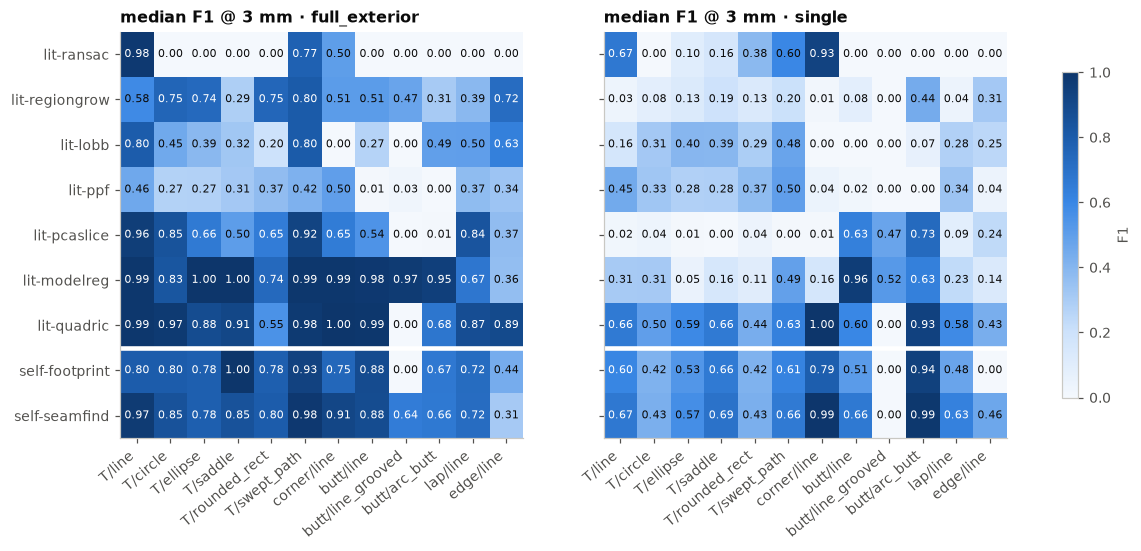

                  self-footprint        self-seamfind        best of seven       
condition          full_exterior single full_exterior single full_exterior single
stratum                                                                          
T/line                      0.80   0.60          0.97   0.67          0.99   0.67
T/circle                    0.80   0.42          0.85   0.43          0.97   0.50
T/ellipse                   0.78   0.53          0.78   0.57          1.00   0.59
T/saddle                    1.00   0.66          0.85   0.69          1.00   0.66
T/rounded_rect              0.78   0.42          0.80   0.43          0.75   0.44
T/swept_path                0.93   0.61          0.98   0.66          0.99   0.63
corner/line                 0.75   0.79          0.91   0.99          1.00   1.00
butt/line                   0.88   0.51          0.88   0.66          0.99   0.96
butt/line_grooved           0.00   0.00          0.64   0.00          0.97   0.52
butt/arc_butt   

In [5]:
DF = pd.read_csv("../out/phase4_batch/phase4_batch.csv.gz", low_memory=False,
                 usecols=["chunk", "method", "scene_id", "condition", "seed", "f1", "precision", "recall", "rmse_med"])
cov = DF[DF.chunk.str.startswith("coverage_")].merge(FACTS[["scene_id", "stratum"]], on="scene_id")
cov = cov.groupby(["method", "condition", "stratum", "scene_id"])[["f1", "rmse_med"]].median().reset_index()
SF = pd.read_csv("../out/self_footprint/self_footprint.csv.gz"); SF = SF[SF.gap == "wps"]
ALL = pd.concat([cov, SF[["method", "condition", "stratum", "scene_id", "f1", "rmse_med"]],
                 head[["method", "condition", "stratum", "scene_id", "f1", "rmse_med"]]], ignore_index=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, cond in zip(axes, ("full_exterior", "single")):
    M = ALL[ALL.condition == cond].pivot_table(index="method", columns="stratum", values="f1", aggfunc="median").reindex(index=METHODS, columns=ORDER_STRATA)
    im = ax.imshow(M.values, cmap=SEQ, vmin=0, vmax=1, aspect="auto")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            if np.isfinite(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if v > 0.6 else INK)
    ax.set_xticks(range(len(ORDER_STRATA))); ax.set_xticklabels(ORDER_STRATA, rotation=40, ha="right")
    ax.set_yticks(range(len(METHODS))); ax.set_yticklabels(METHODS); ax.grid(False)
    ax.axhline(6.5, color="white", linewidth=3)
    ax.set_title(f"median F1 @ 3 mm · {cond}", loc="left")
fig.colorbar(im, ax=axes, shrink=0.8, label="F1")
plt.show()
best7 = ALL[ALL.method.str.startswith("lit-")].groupby(["condition", "stratum", "method"]).f1.median().groupby(["condition", "stratum"]).max()
mine = {m: ALL[ALL.method == m].groupby(["condition", "stratum"]).f1.median() for m in ("self-footprint", "self-seamfind")}
print(pd.DataFrame({**mine, "best of seven": best7}).unstack("condition").reindex(ORDER_STRATA).round(2).to_string())
print("\nmatched-path RMSE (mm), full_exterior, median per stratum")
print(ALL[ALL.condition == "full_exterior"].pivot_table(index="stratum", columns="method", values="rmse_med", aggfunc="median").reindex(index=ORDER_STRATA, columns=METHODS).round(2).to_string())

## What the plan also measures — gap and joint angle

The plan's evaluation asks for the gap error and the angle error, which the benchmark can score
because both are constructed: `root_gap_mm` per scene and `dihedral_deg` per truth seam (the
design included angle is one number per scene, but an angled T has α on one side and 180° − α on
the other, and an oblique stub's dihedral varies around its ring - so the per-seam truth is the
reference). Per scene, the median over the returned seams of the walkers' toe-to-toe gap and of
the dihedral `180° − θ_n`, against the scene's root gap and the median of its truth seams'
mean dihedrals; fillet strata only for the angle.

gap error (mm), per stratum:
                   count  mean   50%   95%
stratum                                   
T/line              59.0  1.30  0.95  4.03
T/circle            60.0  0.88  0.34  4.35
T/ellipse           60.0  1.06  0.42  5.00
T/saddle            60.0  1.95  1.12  5.32
T/rounded_rect      60.0  1.09  0.37  5.00
T/swept_path        60.0  1.15  0.28  5.72
corner/line         57.0  1.77  1.79  3.07
butt/line           60.0  1.11  0.92  2.94
butt/line_grooved   59.0  1.24  0.96  2.88
butt/arc_butt       60.0  0.78  0.40  3.01
lap/line            60.0  1.93  1.45  4.98
edge/line           58.0  1.23  1.12  2.38

estimated - truth dihedral (deg), fillet strata:
                count  mean  50%   95%
stratum                               
T/circle         60.0  -2.9 -1.3   0.3
T/ellipse        60.0  -0.1  0.1   9.9
T/line           59.0   0.1  0.0  23.2
T/rounded_rect   60.0  -1.8 -0.0   0.0
T/saddle         60.0  -8.1 -7.6   3.0
T/swept_path     60.0  -0.6 -0.1   0.5
corner/

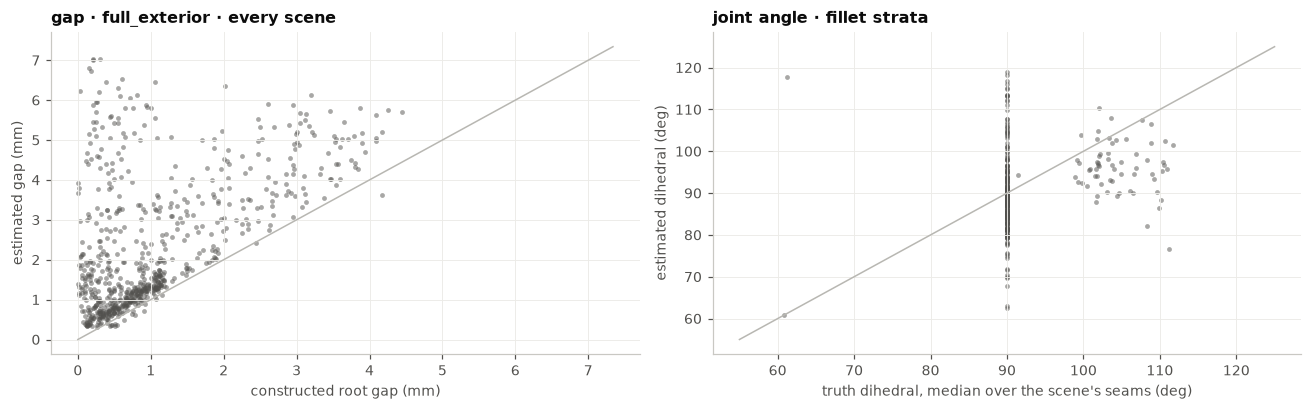

In [6]:
import json
def truth_dihedral(r):
    s = json.load(open(f"../out/bench_phase4/{r.joint_type}/{r.scene_id}/scene.json"))
    d = lambda x: x["dihedral_deg"]["mean"] if isinstance(x["dihedral_deg"], dict) else x["dihedral_deg"]   # curved: min/mean/max; straight: one value
    v = [d(x) for x in s["seams"] if x["weldable"] and x["matches_joint_type"] and x.get("dihedral_deg") is not None]
    return float(np.median(v)) if v else np.nan
FACTS["dihedral_truth"] = [truth_dihedral(r) for r in FACTS.itertuples()]
q = head[head.condition == "full_exterior"].merge(FACTS[["scene_id", "dihedral_truth"]], on="scene_id")
q["gap_err"] = q.gap_est_med - q.root_gap_mm
fil = q[q.stratum.isin(["T/line", "T/circle", "T/ellipse", "T/saddle", "T/rounded_rect", "T/swept_path", "corner/line"])].copy()
fil["ang_err"] = fil.dihedral_med - fil.dihedral_truth
print("gap error (mm), per stratum:"); print(q.groupby("stratum").gap_err.describe(percentiles=[.5, .95])[["count", "mean", "50%", "95%"]].reindex(ORDER_STRATA).round(2).to_string())
print("\nestimated - truth dihedral (deg), fillet strata:"); print(fil.groupby("stratum").ang_err.describe(percentiles=[.5, .95])[["count", "mean", "50%", "95%"]].round(1).to_string())
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].scatter(q.root_gap_mm, q.gap_est_med, s=10, color=COLOR["self-seamfind"], alpha=0.5, linewidths=0)
lim = [0, max(q.root_gap_mm.max(), np.nanmax(q.gap_est_med)) + 0.3]; axes[0].plot(lim, lim, color=GRAY, linewidth=1)
axes[0].set_xlabel("constructed root gap (mm)"); axes[0].set_ylabel("estimated gap (mm)"); axes[0].set_title("gap · full_exterior · every scene", loc="left")
axes[1].scatter(fil.dihedral_truth, fil.dihedral_med, s=10, color=COLOR["self-seamfind"], alpha=0.5, linewidths=0)
axes[1].plot([55, 125], [55, 125], color=GRAY, linewidth=1)
axes[1].set_xlabel("truth dihedral, median over the scene's seams (deg)"); axes[1].set_ylabel("estimated dihedral (deg)"); axes[1].set_title("joint angle · fillet strata", loc="left")
plt.tight_layout(); plt.show()

## Reading it

**The corpus-fitted pipeline is what works; the plan as written does not.** Over 720 scenes the
`default` arm averages a stratum-median F1 of 0.78 (full view) and 0.60 (single view); the
`plan` arm, the plan's own settings where they differ, scores 0.03 and 0.25. The gap is mostly
seeding: mutual nearest neighbours leave one pair per 2–3 mm per side and the θ_r test drops the
curved seams. The crease-free refit of the supporting planes is worth 0.19 in full view
(`nocrease` 0.59) and nothing in single view, where the buried-face strips it removes are out of
sight anyway.

**Coverage.** Full view: median F1 0.78–0.98 on the six T strata, 0.91 on corner, 0.88 on
square butt. Single view: corner 0.99, arc butt 0.99, the T strata 0.43–0.69
(half of each ring is out of view, the same ceiling every method has).

**Against the seven and `self-footprint`.** In full view within 0.02–0.15 of the best of the
seven on 7 of the 12 strata, further behind on ellipse (0.22), arc butt (0.29), grooved butt
(0.33) and edge (0.58); at or above it on the rounded rectangle (0.80 vs 0.75, full), and in single view
on the saddle (0.69 vs 0.66), swept path (0.66 vs 0.63), arc butt (0.99 vs 0.93), lap (0.63 vs
0.58) and edge (0.46 vs 0.43). It beats `self-footprint` on 11 of 12 strata in single view (ties at 0 on the grooved butt) and
is the only one of the two that finds grooved butts at all (0.64 full view, through the
coplanar pairing of Stage 3b). The seven are scored with a truth-derived coarse stage each;
this method gets the part labels.

**Path accuracy.** The lowest matched-path RMSE of all nine entries on 8 of the 12 strata in
full view: all six T strata (0.25–0.42 mm), corner (0.26) and arc butt (0.43). Where it is not
lowest: square butt (1.20 vs `self-footprint` 0.91), lap (1.20 vs `lit-lobb` 0.88), edge (2.35)
and the grooved butt (5.1 mm - Stage 3b finds the top-face centreline but the root-face pairs
still pull part of the path a groove depth down).

**Joint angle: good. Gap: not yet.** The dihedral from the refitted planes is within 1.3° of the
truth seams' (median) on five of the seven fillet strata, −7.6° on the saddle (the ring's
dihedral varies by tens of degrees and the scene median smooths it differently) and +3.0° on
corners. The gap estimate is biased upwards: median error +0.3 to +1.8 mm, 95th percentile up
to 5.7 mm. The toe-to-toe distance is taken where the walkers stop, and on random samples a
walker stalls (`d_prev − d < tol`) or meets its patch boundary before the true toe; a
gap-specific estimate (e.g. the closest-pair distance between the refitted faces at the root)
is the next step.

**Where it fails.** Edge joints in full view (0.31): 55 of the 60 scenes have 1–2 mm plates,
whose edge faces are one or two samples wide (the thin-sheet limit, `seamfind/README.md`).
Grooved butts in single view (0): the single camera rarely sees both top faces of the groove.
Lap joints keep false positives in full view (precision 0.76).

**Deterministic.** Zero seed spread on every scene-condition cell of the live round. Three
single-view scenes see no point of part A at all; they return no seam and score 0.